In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
df=pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [37]:
df=df[["GrLivArea","BedroomAbvGr","FullBath","SalePrice"]]
df.head()

,GrLivArea,BedroomAbvGr,FullBath,SalePrice
0,1710,3,2,208500
1,1262,3,2,181500
2,1786,3,2,223500
3,1717,3,1,140000
4,2198,4,2,250000


In [39]:
df.describe()

,GrLivArea,BedroomAbvGr,FullBath,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,1515.463699,2.866438,1.565068,180921.195890
std,525.480383,0.815778,0.550916,79442.502883
min,334.000000,0.000000,0.000000,34900.000000
25%,1129.500000,2.000000,1.000000,129975.000000
50%,1464.000000,3.000000,2.000000,163000.000000
75%,1776.750000,3.000000,2.000000,214000.000000
max,5642.000000,8.000000,3.000000,755000.000000


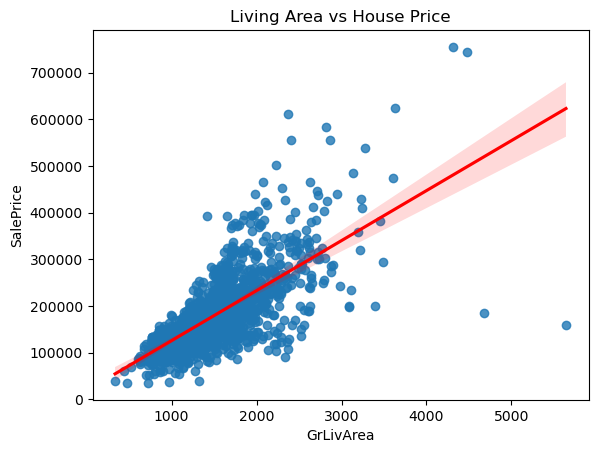

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x="GrLivArea", y="SalePrice", data=df, line_kws={"color": "red"})
plt.title("Living Area vs House Price")
plt.show()

## 📊 Relationship Between Living Area and House Price

The scatter plot shows the relationship between above-ground living area (GrLivArea) and house price (SalePrice).

Most of the data points are concentrated between approximately 500 and 2,300 square feet. Within this range, there is a clear positive linear relationship, where an increase in living area leads to an increase in house price.

The red regression line confirms this positive trend, indicating that larger houses generally have higher prices.

However, there are several noticeable outliers in the data. For example, houses with very large living areas (around 5,500 square feet) have relatively low prices, same price as compare to houses with much smaller living areas (around 2,000 square feet). These observations do not follow the general trend.

These outliers may negatively affect the regression model and suggest that other important factors, such as location or house quality, are not included in the model.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["GrLivArea", "BedroomAbvGr", "FullBath"]]
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_pred = model.predict(X_test)

In [25]:
y_pred[:5]

array([187858.55277535, 212591.40104557, 191031.89284168, 105828.91043586,
       185312.79016643])

In [26]:
y_test[:5]

738     179000
953     172000
108     115000
912      88000
1403    282922
Name: SalePrice, dtype: int64

In [28]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred)

print("MSE:", mse)

MSE: 2128723680.7629704


In [30]:
import numpy as np
rmse=np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 46138.093596972234


## 📊 Model Evaluation (RMSE)

The model was evaluated using Root Mean Squared Error (RMSE).

The RMSE is approximately 46,138, which means that on average, the model's predicted house prices differ from the actual prices by about $46,000.

Considering that house prices range between approximately $100,000 and $300,000, this represents a moderate level of prediction error.

The error can be attributed to several factors, including the use of only a limited number of features, the presence of outliers, and the non-linear patterns observed in the data.

In [32]:
print("Coefficient:", model.coef_)
print("Intercept:",model.intercept_)

Coefficient: [   107.90759765 -27106.81833449  31033.36838748]
Intercept: 46589.785441066604


## 📊 Regression Coefficients Interpretation

The regression model provides coefficients that describe the relationship between each feature and the house price.

- **GrLivArea (Living Area):**  
  The coefficient is approximately 107.91, indicating that for every additional square foot of living area, the house price increases by about $107.91, holding other variables constant.
 
- **BedroomAbvGr (Number of Bedrooms):**  
  The coefficient is approximately -27,106, indicating that, holding other variables constant, an increase in the number of bedrooms is associated with a decrease in house price.

  This result may seem counterintuitive, but it can be explained by the relationship between variables. When the total living area is held constant, adding more bedrooms may result in smaller room sizes or lower overall space quality, which can reduce the house value.

  Additionally, this effect may be influenced by multicollinearity between living area and number of bedrooms.

- **FullBath (Number of Bathrooms):**  
  The coefficient is approximately 31,033, suggesting that each additional bathroom increases the house price by about $31,033.

- **Intercept:**  
  The intercept is approximately 46,589, representing the baseline predicted price when all variables are zero. Although not realistic, it is necessary for the regression equation.

Overall, the model indicates that living area is the most influential factor, while bedrooms and bathrooms also contribute positively to the house price.

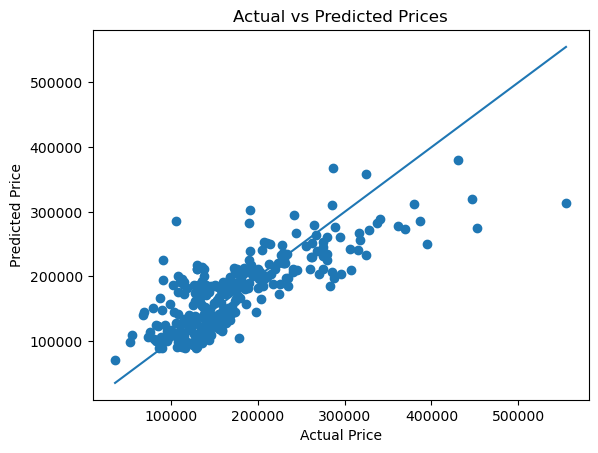

In [35]:


import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

## 📊 Actual vs Predicted Prices

The scatter plot compares the actual house prices with the predicted values from the regression model.

Most of the points are relatively close to the reference line, indicating that the model performs reasonably well for many observations.

However, there are several outliers where the model significantly underestimates the actual price. For example, houses with actual prices around $50,000 are predicted to be only around $20,000–$30,000.

Additionally, the model performs better for lower price ranges (approximately $10,000 to $20,000), where predictions are closer to actual values. As the house price increases beyond approximately $23,000–$25,000, the predicted values tend to fall below the reference line.

This suggests that the model systematically underestimates higher-priced houses. This limitation is likely due to the simplicity of the model and the exclusion of other important features such as location, quality, and additional house characteristics.